# Part 3

### A. Returns in USD

In [3651]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Preliminaries : setting the data

In [3652]:
# Create dataframe with conversion rate
aud_to_usd = pd.read_csv('./data/EXUSAL.csv') # aud to usd
eur_to_usd = pd.read_csv('./data/EXUSEU.csv') # eur to usd
jpy_to_usd = pd.read_csv('./data/EXJPUS.csv') # usd to jpy
chf_to_usd = pd.read_csv('./data/EXSZUS.csv') # usd to chf
gbp_to_usd = pd.read_csv('./data/EXUSUK.csv') # gbp to usd

aud_to_usd = aud_to_usd.rename(columns={'EXUSAL': 'exchange_rate'})
eur_to_usd = eur_to_usd.rename(columns={'EXUSEU': 'exchange_rate'})
jpy_to_usd = jpy_to_usd.rename(columns={'EXJPUS': 'exchange_rate'})
chf_to_usd = chf_to_usd.rename(columns={'EXSZUS': 'exchange_rate'})
gbp_to_usd = gbp_to_usd.rename(columns={'EXUSUK': 'exchange_rate'})

In [3653]:
# handle NaN values
aud_to_usd['exchange_rate'] = aud_to_usd['exchange_rate'].interpolate(method='linear') 
eur_to_usd['exchange_rate'] = eur_to_usd['exchange_rate'].interpolate(method='linear')
jpy_to_usd['exchange_rate'] = 1/jpy_to_usd['exchange_rate'].interpolate(method='linear')
chf_to_usd['exchange_rate'] = 1/chf_to_usd['exchange_rate'].interpolate(method='linear')
gbp_to_usd['exchange_rate'] = gbp_to_usd['exchange_rate'].interpolate(method='linear')

In [3654]:
#transform these exchange rates into FX returns 
aud_to_usd['FX_return'] = (aud_to_usd['exchange_rate'] - aud_to_usd['exchange_rate'].shift(1)) / aud_to_usd['exchange_rate'].shift(1)
eur_to_usd['FX_return'] = (eur_to_usd['exchange_rate'] - eur_to_usd['exchange_rate'].shift(1)) / eur_to_usd['exchange_rate'].shift(1)
jpy_to_usd['FX_return'] = (jpy_to_usd['exchange_rate'] - jpy_to_usd['exchange_rate'].shift(1)) / jpy_to_usd['exchange_rate'].shift(1)
chf_to_usd['FX_return'] = (chf_to_usd['exchange_rate'] - chf_to_usd['exchange_rate'].shift(1)) / chf_to_usd['exchange_rate'].shift(1)
gbp_to_usd['FX_return'] = (gbp_to_usd['exchange_rate'] - gbp_to_usd['exchange_rate'].shift(1)) / gbp_to_usd['exchange_rate'].shift(1)


In [3655]:
#drop NaN
aud_to_usd = aud_to_usd.dropna()
eur_to_usd = eur_to_usd.dropna()
jpy_to_usd = jpy_to_usd.dropna()
chf_to_usd = chf_to_usd.dropna()
gbp_to_usd = gbp_to_usd.dropna()

print(aud_to_usd.tail())
print(eur_to_usd.tail())
print(jpy_to_usd.tail())
print(chf_to_usd.tail())
print(gbp_to_usd.tail())

    observation_date  exchange_rate  FX_return
271       2024-08-01         0.6658  -0.002248
272       2024-09-01         0.6770   0.016822
273       2024-10-01         0.6700  -0.010340
274       2024-11-01         0.6528  -0.025672
275       2024-12-01         0.6334  -0.029718
    observation_date  exchange_rate  FX_return
271       2024-08-01         1.1020   0.015949
272       2024-09-01         1.1104   0.007623
273       2024-10-01         1.0895  -0.018822
274       2024-11-01         1.0621  -0.025149
275       2024-12-01         1.0472  -0.014029
    observation_date  exchange_rate  FX_return
268       2024-08-01       0.006837   0.076944
269       2024-09-01       0.006995   0.023155
270       2024-10-01       0.006672  -0.046280
271       2024-11-01       0.006506  -0.024863
272       2024-12-01       0.006501  -0.000661
    observation_date  exchange_rate  FX_return
271       2024-08-01       1.165637   0.039399
272       2024-09-01       1.180359   0.012630
273       202

In [3656]:
# Load the stocks per country
world_data = pd.read_csv('./data/country_data.csv', sep=';')

australia = world_data[world_data.country == 'AUSTRALIA'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
france = world_data[world_data.country == 'FRANCE'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
germany = world_data[world_data.country == 'GERMANY'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
japan = world_data[world_data.country == 'JAPAN'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
switzerland = world_data[world_data.country == 'SWITZERLAND'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
britain = world_data[world_data.country == 'UNITED KINGDOM'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})

# Load the stocks for the US
usa = pd.read_csv('./data/crsp_value_weighted_returns.csv', sep=';').rename(columns={'vwretx': 'monthly_price_return', 'vwretd': 'monthly_total_return'})

In [3657]:
jpy_to_usd

,observation_date,exchange_rate,FX_return
1,2002-05-01,0.007913,0.034792
2,2002-06-01,0.008111,0.025018
3,2002-07-01,0.008482,0.045729
4,2002-08-01,0.008404,-0.009190
5,2002-09-01,0.008259,-0.017223
...,...,...,...
268,2024-08-01,0.006837,0.076944
269,2024-09-01,0.006995,0.023155
270,2024-10-01,0.006672,-0.046280
271,2024-11-01,0.006506,-0.024863


In [3658]:
# adjust dates
aud_to_usd['observation_date'] = (pd.to_datetime(aud_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
eur_to_usd['observation_date'] = (pd.to_datetime(eur_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
jpy_to_usd['observation_date'] = (pd.to_datetime(jpy_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
chf_to_usd['observation_date'] = (pd.to_datetime(chf_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
gbp_to_usd['observation_date'] = (pd.to_datetime(gbp_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')

australia['date'] = pd.to_datetime(australia['date']).dt.strftime('%Y-%m')
france['date'] = pd.to_datetime(france['date']).dt.strftime('%Y-%m')
japan['date'] = pd.to_datetime(japan['date']).dt.strftime('%Y-%m')
germany['date'] = pd.to_datetime(germany['date']).dt.strftime('%Y-%m')
switzerland['date'] = pd.to_datetime(switzerland['date']).dt.strftime('%Y-%m')
usa['date'] = pd.to_datetime(usa['date']).dt.strftime('%Y-%m')
britain['date'] = pd.to_datetime(britain['date']).dt.strftime('%Y-%m')

In [3659]:
jpy_to_usd

,observation_date,exchange_rate,FX_return
1,2002-04,0.007913,0.034792
2,2002-05,0.008111,0.025018
3,2002-06,0.008482,0.045729
4,2002-07,0.008404,-0.009190
5,2002-08,0.008259,-0.017223
...,...,...,...
268,2024-07,0.006837,0.076944
269,2024-08,0.006995,0.023155
270,2024-09,0.006672,-0.046280
271,2024-10,0.006506,-0.024863


In [3660]:
# Compute returns in USD
australia = australia.iloc[3:].merge(aud_to_usd, left_on='date', right_on='observation_date')
australia['monthly_total_return_USD'] = (1+australia['monthly_total_return'])*(1+australia['FX_return'])-1
australia['monthly_price_return_USD'] = (1+australia['monthly_price_return'])*(1+australia['FX_return'])-1
australia = australia.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

france = france.iloc[3:].merge(eur_to_usd, left_on='date', right_on='observation_date')
france['monthly_total_return_USD'] = (1+france['monthly_total_return'])*(1+france['FX_return'])-1
france['monthly_price_return_USD'] = (1+france['monthly_price_return'])*(1+france['FX_return'])-1
france = france.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

germany = germany.iloc[3:].merge(eur_to_usd, left_on='date', right_on='observation_date')
germany['monthly_total_return_USD'] = (1+germany['monthly_total_return'])*(1+germany['FX_return'])-1
germany['monthly_price_return_USD'] = (1+germany['monthly_price_return'])*(1+germany['FX_return'])-1
germany = germany.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

japan = japan.merge(jpy_to_usd, left_on='date', right_on='observation_date')
japan['monthly_total_return_USD'] = (1+japan['monthly_total_return'])*(1+japan['FX_return'])-1
japan['monthly_price_return_USD'] = (1+japan['monthly_price_return'])*(1+japan['FX_return'])-1
japan = japan.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

switzerland = switzerland.iloc[3:].merge(chf_to_usd, left_on='date', right_on='observation_date')
switzerland['monthly_total_return_USD'] = (1+switzerland['monthly_total_return'])*(1+switzerland['FX_return'])-1
switzerland['monthly_price_return_USD'] = (1+switzerland['monthly_price_return'])*(1+switzerland['FX_return'])-1
switzerland = switzerland.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

britain = britain.iloc[3:].merge(gbp_to_usd, left_on='date', right_on='observation_date')
britain['monthly_total_return_USD'] = (1+britain['monthly_total_return'])*(1+britain['FX_return'])-1
britain['monthly_price_return_USD'] = (1+britain['monthly_price_return'])*(1+britain['FX_return'])-1
britain = britain.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

usa = usa.iloc[3:-1].reset_index(drop=True)
usa

,date,monthly_price_return,monthly_total_return
0,2002-04,-0.050504,-0.049600
1,2002-05,-0.011958,-0.010510
2,2002-06,-0.071515,-0.070259
3,2002-07,-0.082310,-0.081125
4,2002-08,0.006405,0.007949
...,...,...,...
267,2024-07,0.019000,0.019878
268,2024-08,0.020203,0.021572
269,2024-09,0.019485,0.020969
270,2024-10,-0.009139,-0.008298


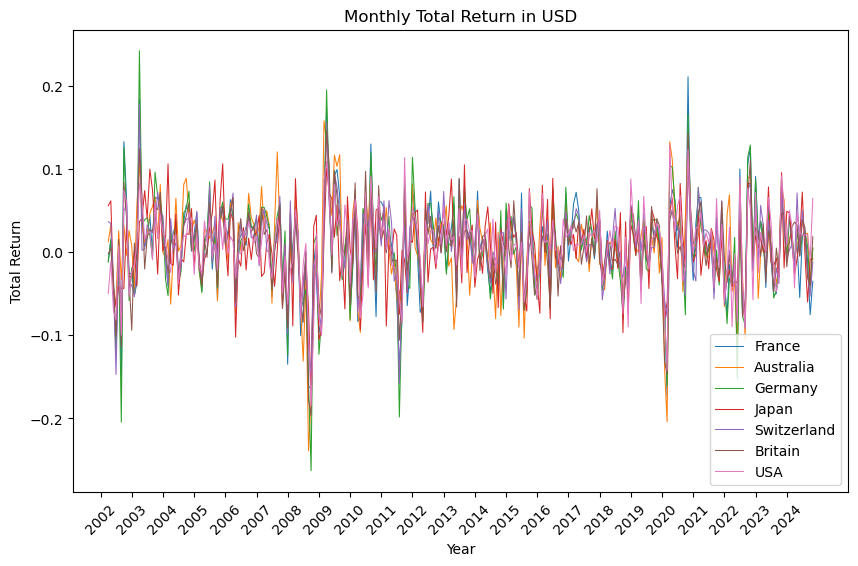

In [3661]:
import matplotlib.dates as mdates

france['date'] = pd.to_datetime(france['date'])
australia['date'] = pd.to_datetime(australia['date'])
germany['date'] = pd.to_datetime(germany['date'])
japan['date'] = pd.to_datetime(japan['date'])
switzerland['date'] = pd.to_datetime(switzerland['date'])
britain['date'] = pd.to_datetime(britain['date'])
usa['date'] = pd.to_datetime(usa['date']) 

plt.figure(figsize=(10,6))
plt.plot(france['date'], france['monthly_total_return_USD'], label='France', linestyle='-', linewidth=0.75)
plt.plot(australia['date'], australia['monthly_total_return_USD'], label='Australia', linestyle='-', linewidth=0.75)
plt.plot(germany['date'], germany['monthly_total_return_USD'], label='Germany', linestyle='-', linewidth=0.75)
plt.plot(japan['date'], japan['monthly_total_return_USD'], label='Japan', linestyle='-', linewidth=0.75)
plt.plot(switzerland['date'], switzerland['monthly_total_return_USD'], label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(britain['date'], britain['monthly_total_return_USD'], label='Britain', linestyle='-', linewidth=0.75)
plt.plot(usa['date'], usa['monthly_total_return'], label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Total Return')
plt.show()


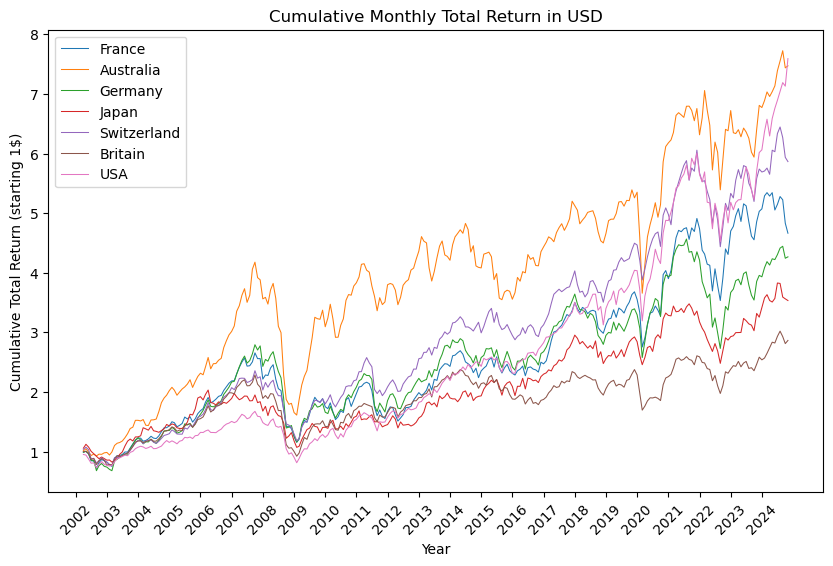

In [3662]:
plt.figure(figsize=(10,6))
plt.plot(france['date'], (1 + france['monthly_total_return_USD']).cumprod(), label='France', linestyle='-', linewidth=0.75)
plt.plot(australia['date'], (1 + australia['monthly_total_return_USD']).cumprod(), label='Australia', linestyle='-', linewidth=0.75)
plt.plot(germany['date'], (1 + germany['monthly_total_return_USD']).cumprod(), label='Germany', linestyle='-', linewidth=0.75)
plt.plot(japan['date'], (1 + japan['monthly_total_return_USD']).cumprod(), label='Japan', linestyle='-', linewidth=0.75)
plt.plot(switzerland['date'], (1 + switzerland['monthly_total_return_USD']).cumprod(), label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(britain['date'], (1 + britain['monthly_total_return_USD']).cumprod(), label='Britain', linestyle='-', linewidth=0.75)
plt.plot(usa['date'], (1 + usa['monthly_total_return']).cumprod(), label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Cumulative Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Cumulative Total Return (starting 1$)')
plt.show()

In [3663]:
df = pd.DataFrame({
    'date': usa['date'].dt.strftime('%m-%Y'),
    'France': france['monthly_total_return_USD'],
    'Australia': australia['monthly_total_return_USD'],
    'Germany': germany['monthly_total_return_USD'],
    'Japan': japan['monthly_total_return_USD'],
    'Switzerland': switzerland['monthly_total_return_USD'],
    'Britain': britain['monthly_total_return_USD'],
    'USA': usa['monthly_total_return']
})

df.to_csv('./data/USD_monthly_returns.csv', index=False)

df

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,04-2002,-0.010538,0.012587,-0.011617,0.056094,0.036820,-0.001806,-0.049600
1,05-2002,0.013428,0.033256,0.015840,0.061906,0.034877,0.004702,-0.010510
2,06-2002,-0.044850,-0.051421,-0.032251,-0.041866,-0.039197,-0.037508,-0.070259
3,07-2002,-0.117957,-0.059533,-0.122706,-0.066380,-0.147091,-0.101053,-0.081125
4,08-2002,-0.002077,0.025970,-0.000348,-0.041213,0.007842,0.015599,0.007949
...,...,...,...,...,...,...,...,...
267,07-2024,0.018647,0.035730,0.019748,0.072474,0.050481,0.039456,0.019878
268,08-2024,0.025529,0.021983,0.025336,-0.001815,0.017400,0.029770,0.021572
269,09-2024,-0.010247,0.022941,0.007013,-0.059865,-0.027682,-0.030240,0.020969
270,10-2024,-0.075214,-0.037250,-0.045202,-0.008310,-0.052857,-0.040088,-0.008298


### B. Currency hedged 

In [3664]:
# Load the risk free rate and 3-month interbank rate
r_f = pd.read_csv('./data/tbill.csv', sep=';')
aud_rate = pd.read_csv('./data/AUSTRALIA.csv')
eur_rate = pd.read_csv('./data/EUROPE.csv')
jpy_rate = pd.read_csv('./data/JAPAN.csv')
chf_rate = pd.read_csv('./data/SWITZERLAND.csv')
gbp_rate = pd.read_csv('./data/GREATBRITAIN.csv')
usd_rate = pd.read_csv('./data/USA.csv')

aud_rate = aud_rate.rename(columns={'IR3TIB01AUM156N':'exchange_rate'}) 
eur_rate = eur_rate.rename(columns={'IR3TIB01EZM156N':'exchange_rate'})
jpy_rate = jpy_rate.rename(columns={'IR3TIB01JPM156N':'exchange_rate'})
chf_rate = chf_rate.rename(columns={'IR3TIB01CHM156N':'exchange_rate'})
gbp_rate = gbp_rate.rename(columns={'IR3TIB01GBM156N':'exchange_rate'})
usd_rate = usd_rate.rename(columns={'IR3TIB01USM156N':'exchange_rate'})

# usd_rate['returns'] =  (usd_rate['exchange_rate']/ usd_rate['exchange_rate'].shift(1)) - 1
# eur_rate['returns'] =  (eur_rate['exchange_rate']/ eur_rate['exchange_rate'].shift(1)) - 1
# jpy_rate['returns'] =  (jpy_rate['exchange_rate']/ jpy_rate['exchange_rate'].shift(1)) - 1
# chf_rate['returns'] =  (chf_rate['exchange_rate']/ chf_rate['exchange_rate'].shift(1)) - 1
# gbp_rate['returns'] =  (gbp_rate['exchange_rate']/ gbp_rate['exchange_rate'].shift(1)) - 1
# aud_rate['returns'] =  (aud_rate['exchange_rate']/ aud_rate['exchange_rate'].shift(1)) - 1

aud_rate = aud_rate.dropna()
eur_rate = eur_rate.dropna()
jpy_rate = jpy_rate.dropna()
chf_rate = chf_rate.dropna()
gbp_rate = gbp_rate.dropna()
usd_rate = usd_rate.dropna()

aud_rate['exchange_rate'] = aud_rate['exchange_rate']/100
eur_rate['exchange_rate'] = eur_rate['exchange_rate']/100
jpy_rate['exchange_rate'] = jpy_rate['exchange_rate']/100
chf_rate['exchange_rate'] = chf_rate['exchange_rate']/100
gbp_rate['exchange_rate'] = gbp_rate['exchange_rate']/100
usd_rate['exchange_rate'] = usd_rate['exchange_rate']/100

jpy_to_usd

,observation_date,exchange_rate,FX_return
1,2002-04,0.007913,0.034792
2,2002-05,0.008111,0.025018
3,2002-06,0.008482,0.045729
4,2002-07,0.008404,-0.009190
5,2002-08,0.008259,-0.017223
...,...,...,...
268,2024-07,0.006837,0.076944
269,2024-08,0.006995,0.023155
270,2024-09,0.006672,-0.046280
271,2024-10,0.006506,-0.024863


In [3665]:
chf_rate

,observation_date,exchange_rate
0,2002-04-01,0.014606
1,2002-05-01,0.011635
2,2002-06-01,0.011496
3,2002-07-01,0.010031
4,2002-08-01,0.006683
...,...,...
268,2024-08-01,0.010665
269,2024-09-01,0.010221
270,2024-10-01,0.008945
271,2024-11-01,0.008065


In [3666]:
aud_rate['observation_date'] = (pd.to_datetime(aud_rate['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
eur_rate['observation_date'] = (pd.to_datetime(eur_rate['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
jpy_rate['observation_date'] = (pd.to_datetime(jpy_rate['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
chf_rate['observation_date'] = (pd.to_datetime(chf_rate['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
gbp_rate['observation_date'] = (pd.to_datetime(gbp_rate['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')

In [3667]:
chf_rate

,observation_date,exchange_rate
0,2002-03,0.014606
1,2002-04,0.011635
2,2002-05,0.011496
3,2002-06,0.010031
4,2002-07,0.006683
...,...,...
268,2024-07,0.010665
269,2024-08,0.010221
270,2024-09,0.008945
271,2024-10,0.008065


In [3668]:
aud_rate = aud_rate.iloc[1:].reset_index(drop=True)
eur_rate = eur_rate.iloc[1:].reset_index(drop=True)
jpy_rate = jpy_rate.iloc[1:].reset_index(drop=True)
chf_rate = chf_rate.iloc[1:].reset_index(drop=True)
gbp_rate = gbp_rate.iloc[1:].reset_index(drop=True)

In [3669]:
chf_to_usd = chf_to_usd[3:].reset_index(drop=True)
chf_rate

,observation_date,exchange_rate
0,2002-04,0.011635
1,2002-05,0.011496
2,2002-06,0.010031
3,2002-07,0.006683
4,2002-08,0.006130
...,...,...
267,2024-07,0.010665
268,2024-08,0.010221
269,2024-09,0.008945
270,2024-10,0.008065


In [3670]:
aud_to_usd = aud_to_usd[3:].reset_index(drop=True)
aud_rate

,observation_date,exchange_rate
0,2002-04,0.0484
1,2002-05,0.0507
2,2002-06,0.0498
3,2002-07,0.0496
4,2002-08,0.0492
...,...,...
267,2024-07,0.0438
268,2024-08,0.0442
269,2024-09,0.0441
270,2024-10,0.0442


In [3671]:
gbp_to_usd = gbp_to_usd[3:].reset_index(drop=True)
gbp_rate

,observation_date,exchange_rate
0,2002-04,0.041537
1,2002-05,0.041776
2,2002-06,0.040605
3,2002-07,0.039865
4,2002-08,0.039887
...,...,...
267,2024-07,0.049100
268,2024-08,0.048400
269,2024-09,0.047500
270,2024-10,0.046800


In [3672]:
eur_to_usd = eur_to_usd[3:].reset_index(drop=True)
jpy_rate

,observation_date,exchange_rate
0,2002-04,0.00080
1,2002-05,0.00090
2,2002-06,0.00090
3,2002-07,0.00070
4,2002-08,0.00080
...,...,...
267,2024-07,0.00255
268,2024-08,0.00256
269,2024-09,0.00256
270,2024-10,0.00362


In [3673]:
# Compute excess returns
excess_ret = pd.DataFrame()
excess_ret['date'] = aud_rate['observation_date']

excess_ret['France'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])
excess_ret['Australia'] = (aud_to_usd['exchange_rate'].shift(-1)/aud_to_usd['exchange_rate'])*(1+aud_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])
excess_ret['Germany'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])
excess_ret['Japan'] = (jpy_to_usd['exchange_rate'].shift(-1)/jpy_to_usd['exchange_rate'])*(1+jpy_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])
excess_ret['Switzerland'] = (chf_to_usd['exchange_rate'].shift(-1)/chf_to_usd['exchange_rate'])*(1+chf_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])
excess_ret['Britain'] = (gbp_to_usd['exchange_rate'].shift(-1)/gbp_to_usd['exchange_rate'])*(1+gbp_rate['exchange_rate'])-(1+usd_rate['exchange_rate'])
excess_ret['USA'] = 0
excess_ret = excess_ret.dropna()
excess_ret['date'] = pd.to_datetime(excess_ret['date']).dt.strftime('%m-%Y')

excess_ret

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
1,05-2002,0.056912,0.005872,0.056912,0.007741,0.040098,0.074692,0
2,06-2002,-0.000029,0.008005,-0.000029,0.028570,-0.025205,0.009335,0
3,07-2002,0.018261,0.041783,0.018261,-0.026397,-0.008452,0.035160,0
4,08-2002,0.016434,0.039003,0.016434,-0.033737,-0.011237,0.023389,0
5,09-2002,0.036166,0.052563,0.036166,-0.039655,0.007489,0.031118,0
...,...,...,...,...,...,...,...,...
266,06-2024,0.000585,-0.010548,0.000585,-0.048966,-0.000996,0.004224,0
267,07-2024,-0.009731,0.008259,-0.009731,0.026590,-0.029671,0.018206,0
268,08-2024,-0.036331,-0.017797,-0.036331,-0.025426,-0.057517,-0.016759,0
269,09-2024,-0.042879,-0.031304,-0.042879,-0.092438,-0.062104,-0.025595,0


In [3674]:
# Assuming 'df' is the dataframe to compare with 'excess_ret'
# Calculate the difference between all columns except 'date'
hedged_returns = df[1:].drop(columns=['date']).subtract(excess_ret.drop(columns=['date']), fill_value=0)
hedged_returns['date'] = df.date
hedged_returns = hedged_returns[['date', 'France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']]

hedged_returns.to_csv('./data/hedged_returns.csv', index=False)

hedged_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
1,05-2002,-0.043484,0.027384,-0.041072,0.054165,-0.005220,-0.069990,-0.010510
2,06-2002,-0.044820,-0.059426,-0.032222,-0.070436,-0.013992,-0.046843,-0.070259
3,07-2002,-0.136217,-0.101316,-0.140967,-0.039983,-0.138639,-0.136213,-0.081125
4,08-2002,-0.018510,-0.013033,-0.016781,-0.007477,0.019080,-0.007790,0.007949
5,09-2002,-0.184251,-0.085605,-0.240585,-0.003898,-0.097013,-0.144854,-0.099923
...,...,...,...,...,...,...,...,...
267,07-2024,0.028378,0.027471,0.029479,0.045884,0.080152,0.021250,0.019878
268,08-2024,0.061860,0.039779,0.061667,0.023611,0.074917,0.046529,0.021572
269,09-2024,0.032633,0.054245,0.049893,0.032573,0.034422,-0.004645,0.020969
270,10-2024,-0.044631,-0.004218,-0.014619,0.059223,-0.002624,-0.033210,-0.008298


C:\Users\eddli\AppData\Local\Temp\ipykernel_31684\1819233065.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hedged_returns['date'] = pd.to_datetime(hedged_returns['date'])


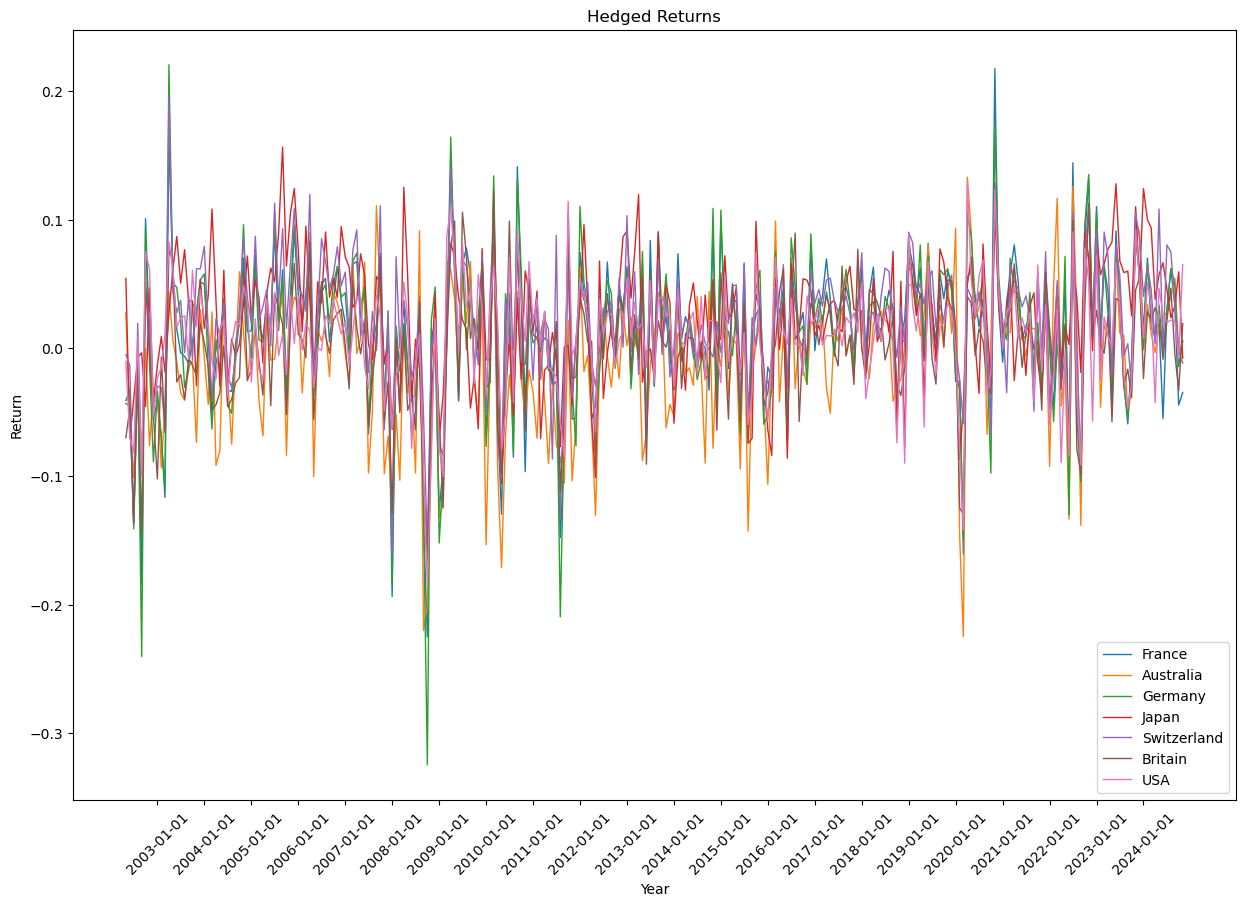

In [3675]:
# US remains USD returns as computed earlier
fig, ax = plt.subplots(figsize=(15, 10))  # Adjust figure size to be slightly smaller

# Convert 'date' column to datetime format for better plotting
hedged_returns['date'] = pd.to_datetime(hedged_returns['date'])

# Plotting each country's returns
for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns['date'], hedged_returns[country], linestyle='-', linewidth=1, label=country)

# Setting x-axis ticks to show unique years and inclining dates by 45 degrees
ax.set_xticks(pd.date_range(start=hedged_returns['date'].min(), end=hedged_returns['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Return')
ax.legend()
plt.show()


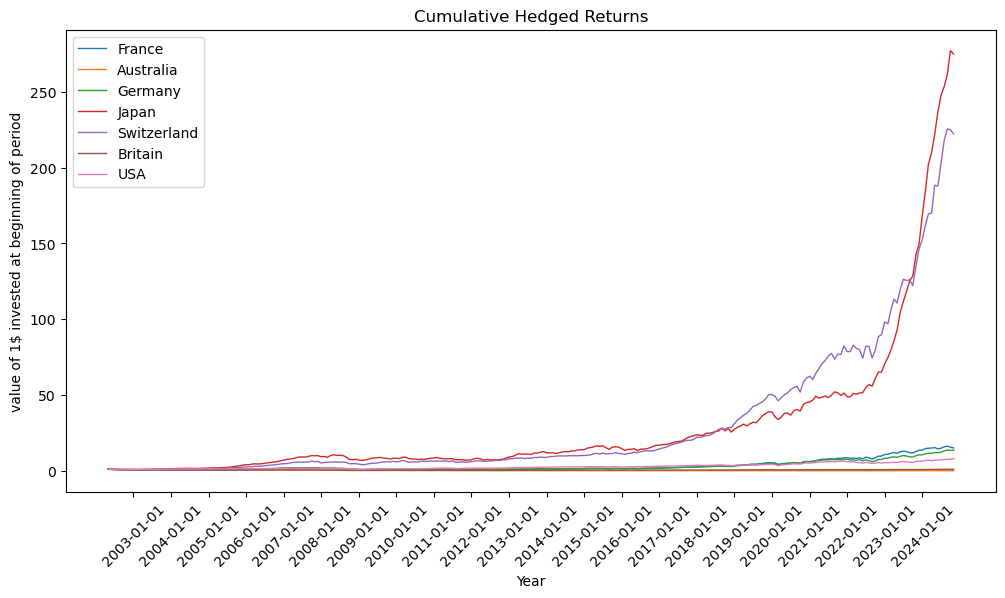

In [3676]:
hedged_returns_cumulative = (1 + hedged_returns.drop(columns=['date'])).cumprod()
hedged_returns_cumulative['date'] = hedged_returns['date']

fig, ax = plt.subplots(figsize=(12, 6))  

for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns_cumulative['date'], hedged_returns_cumulative[country], linestyle='-', linewidth=1, label=country)

ax.set_xticks(pd.date_range(start=hedged_returns_cumulative['date'].min(), end=hedged_returns_cumulative['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Cumulative Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('value of 1$ invested at beginning of period')
ax.legend()
plt.show()

### C. International Diversification

##### *Portfolio of equally weighted indexes*

In [3677]:
# hedged returns
equally_weighted_hedged = pd.DataFrame()
equally_weighted_hedged['date'] = hedged_returns['date']
equally_weighted_hedged['returns'] = hedged_returns.drop(columns='date').sum(axis=1)/6

display(equally_weighted_hedged.returns.describe())

sharpe_ratio = (equally_weighted_hedged['returns'].mean() / equally_weighted_hedged['returns'].std())*np.sqrt(12) #assuming excess returns
print("Sharpe Ratio of Equally Weighted Hedged:", sharpe_ratio)

count    271.000000
mean       0.011297
std        0.053553
min       -0.238010
25%       -0.014832
50%        0.018016
75%        0.045098
max        0.165045
Name: returns, dtype: float64

Sharpe Ratio of Equally Weighted Hedged: 0.7307733252567093


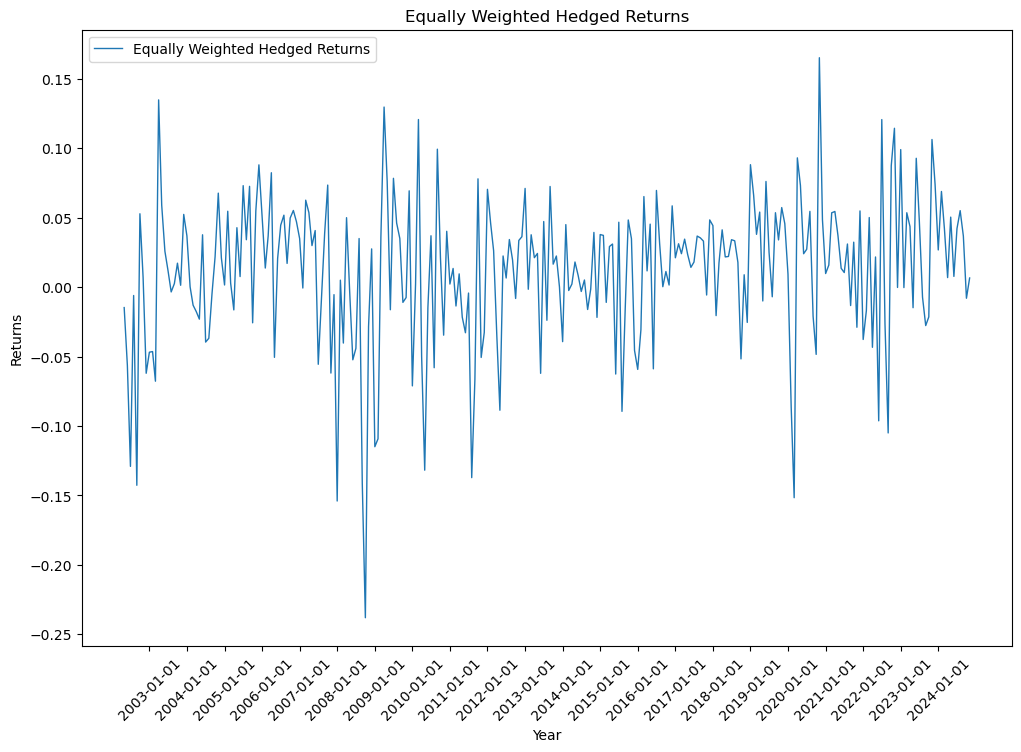

In [3678]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(equally_weighted_hedged['date'], equally_weighted_hedged['returns'], linestyle='-', linewidth=1, label='Equally Weighted Hedged Returns')

ax.set_xticks(pd.date_range(start=equally_weighted_hedged['date'].min(), end=equally_weighted_hedged['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Equally Weighted Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

In [3679]:
# unhedged returns
equally_weighted_unhedged = pd.DataFrame()
equally_weighted_unhedged['date'] = df['date']
equally_weighted_unhedged['returns'] = df.drop(columns='date').sum(axis=1)/6

display(equally_weighted_unhedged.returns.describe())

sharpe_ratio = (equally_weighted_unhedged['returns'].mean() / equally_weighted_unhedged['returns'].std())*np.sqrt(12) #assuning excess returns
print("Sharpe Ratio of Equally Weighted Unhedged:", sharpe_ratio)


count    272.000000
mean       0.008306
std        0.051337
min       -0.217524
25%       -0.017662
50%        0.012426
75%        0.039929
max        0.169562
Name: returns, dtype: float64

Sharpe Ratio of Equally Weighted Unhedged: 0.560448116231684


C:\Users\eddli\AppData\Local\Temp\ipykernel_31684\1541103735.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  equally_weighted_unhedged['date'] = pd.to_datetime(equally_weighted_unhedged['date'])


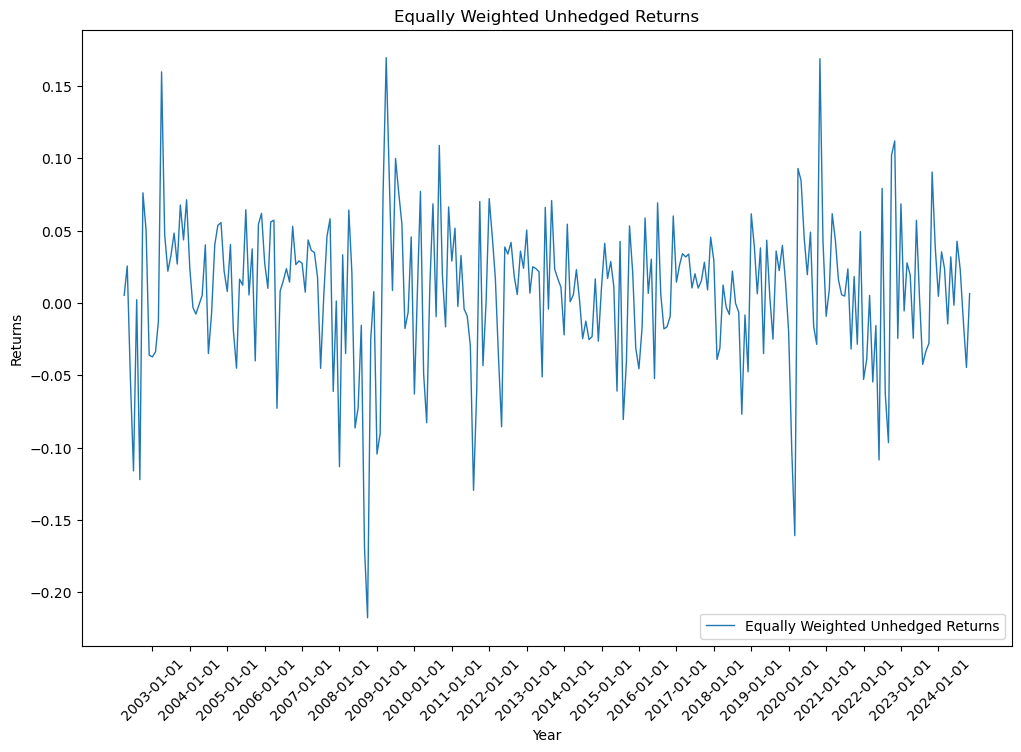

In [3680]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
equally_weighted_unhedged['date'] = pd.to_datetime(equally_weighted_unhedged['date'])
ax.plot(equally_weighted_unhedged['date'], equally_weighted_unhedged['returns'], linestyle='-', linewidth=1, label='Equally Weighted Unhedged Returns')

ax.set_xticks(pd.date_range(start=equally_weighted_unhedged['date'].min(), end=equally_weighted_unhedged['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Equally Weighted Unhedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

#### *Risk parity strategy*

In [3681]:
# Hedged returns 
volatilities = hedged_returns.drop(columns='date').rolling(window=60).std().shift(1) #avoid look ahead bias
volatilities['date'] = hedged_returns.date
volatilities = volatilities.dropna()

hedged_risk_parity = 1/volatilities.drop(columns='date')
hedged_risk_parity = hedged_risk_parity.div(hedged_risk_parity.sum(axis=1), axis=0)
hedged_risk_parity['date'] = volatilities.date

hedged_risk_parity['return'] = (hedged_risk_parity.drop(columns='date')*hedged_returns[hedged_returns['date'].isin(hedged_risk_parity['date'])].drop(columns='date')).sum(axis=1)

display(hedged_risk_parity['return'].describe())
sharpe_ratio = (hedged_risk_parity['return'].mean() / hedged_risk_parity['return'].std())*np.sqrt(12) #assuning excess returns
print("Sharpe Ratio of Hedged Risk Parity:", sharpe_ratio)

count    211.000000
mean       0.009676
std        0.046114
min       -0.200999
25%       -0.013809
50%        0.017080
75%        0.038047
max        0.141140
Name: return, dtype: float64

Sharpe Ratio of Hedged Risk Parity: 0.7268264090825013


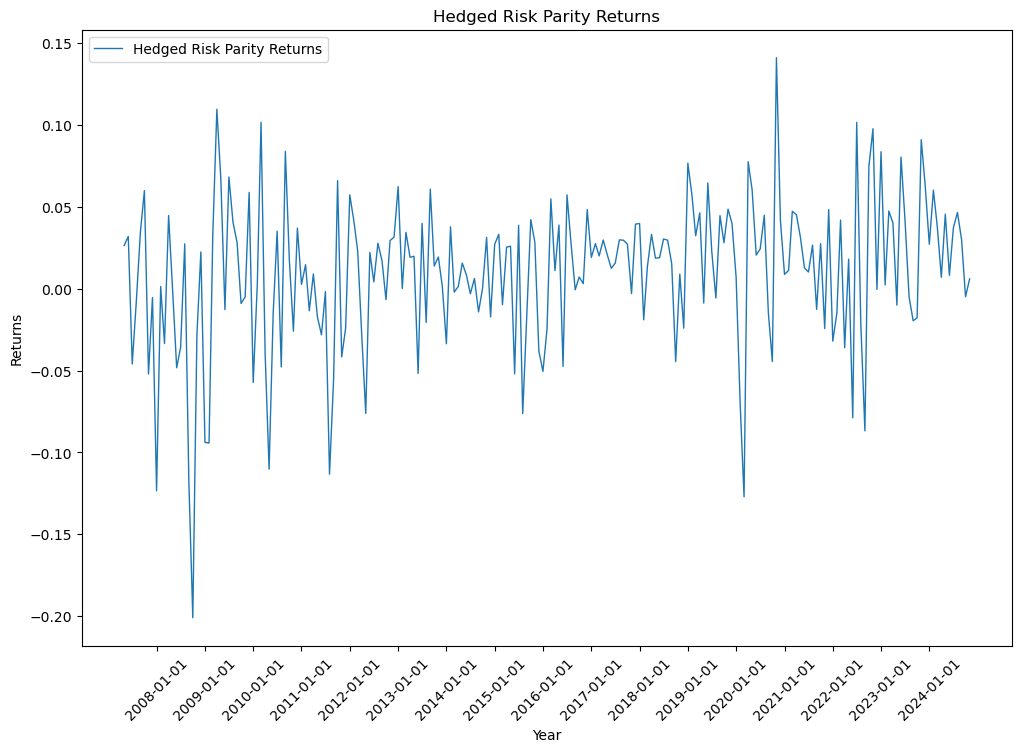

In [3682]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
ax.plot(hedged_risk_parity['date'], hedged_risk_parity['return'], linestyle='-', linewidth=1, label='Hedged Risk Parity Returns')

ax.set_xticks(pd.date_range(start=hedged_risk_parity['date'].min(), end=hedged_risk_parity['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Hedged Risk Parity Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

In [3683]:
# Unhedged Risk parity 
volatilities = df.drop(columns='date').rolling(window=60).std().shift(1) #avoid look ahead bias
volatilities['date'] = df.date
volatilities = volatilities.dropna()

unhedged_risk_parity = 1/volatilities.drop(columns='date')
unhedged_risk_parity = unhedged_risk_parity.div(unhedged_risk_parity.sum(axis=1), axis=0)
unhedged_risk_parity['date'] = volatilities.date

unhedged_risk_parity['return'] = (unhedged_risk_parity.drop(columns='date')*df[df['date'].isin(unhedged_risk_parity['date'])].drop(columns='date')).sum(axis=1)

display(unhedged_risk_parity['return'].describe())
sharpe_ratio = unhedged_risk_parity['return'].mean() / unhedged_risk_parity['return'].std() #assuning excess returns
print("Sharpe Ratio of Unhedged Risk Parity:", sharpe_ratio)

count    212.000000
mean       0.005125
std        0.044684
min       -0.185542
25%       -0.019262
50%        0.008595
75%        0.030591
max        0.143800
Name: return, dtype: float64

Sharpe Ratio of Unhedged Risk Parity: 0.11468828060215978


C:\Users\eddli\AppData\Local\Temp\ipykernel_31684\3695459983.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  unhedged_risk_parity['date'] = pd.to_datetime(unhedged_risk_parity['date'])


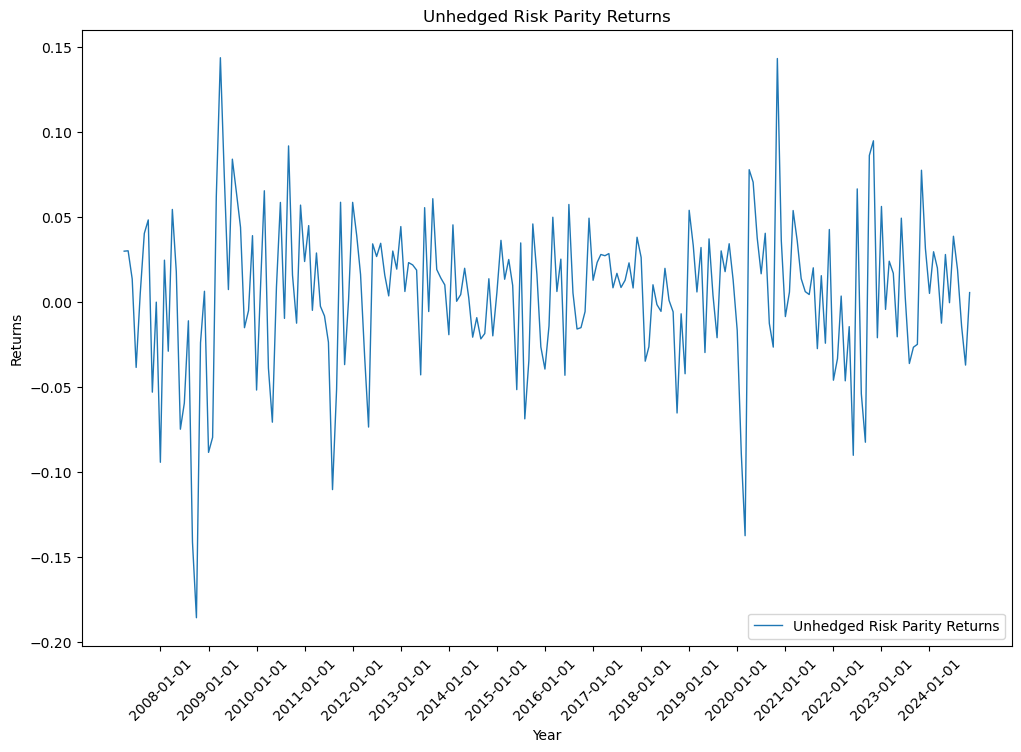

In [3684]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
unhedged_risk_parity['date'] = pd.to_datetime(unhedged_risk_parity['date'])
ax.plot(unhedged_risk_parity['date'], unhedged_risk_parity['return'], linestyle='-', linewidth=1, label='Unhedged Risk Parity Returns')

ax.set_xticks(pd.date_range(start=unhedged_risk_parity['date'].min(), end=unhedged_risk_parity['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('Unhedged Risk Parity Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

##### *MVE portfolio* (assuming risk aversion = 1)

In [3685]:
r_f['tmytm'] = r_f['tmytm']/100

In [3686]:
r_f['mcaldt'] = pd.to_datetime(r_f['mcaldt']) + pd.offsets.MonthBegin(1)
r_f

,mcaldt,tmytm
0,2002-02-01,0.016895
1,2002-03-01,0.017327
2,2002-04-01,0.017098
3,2002-05-01,0.017528
4,2002-06-01,0.016895
...,...,...
271,2024-09-01,0.052564
272,2024-10-01,0.045916
273,2024-11-01,0.045024
274,2024-12-01,0.041699


In [3687]:
hedged_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
1,2002-05-01,-0.043484,0.027384,-0.041072,0.054165,-0.005220,-0.069990,-0.010510
2,2002-06-01,-0.044820,-0.059426,-0.032222,-0.070436,-0.013992,-0.046843,-0.070259
3,2002-07-01,-0.136217,-0.101316,-0.140967,-0.039983,-0.138639,-0.136213,-0.081125
4,2002-08-01,-0.018510,-0.013033,-0.016781,-0.007477,0.019080,-0.007790,0.007949
5,2002-09-01,-0.184251,-0.085605,-0.240585,-0.003898,-0.097013,-0.144854,-0.099923
...,...,...,...,...,...,...,...,...
267,2024-07-01,0.028378,0.027471,0.029479,0.045884,0.080152,0.021250,0.019878
268,2024-08-01,0.061860,0.039779,0.061667,0.023611,0.074917,0.046529,0.021572
269,2024-09-01,0.032633,0.054245,0.049893,0.032573,0.034422,-0.004645,0.020969
270,2024-10-01,-0.044631,-0.004218,-0.014619,0.059223,-0.002624,-0.033210,-0.008298


In [3688]:
# Hedged returns
import numpy as np
import pandas as pd

# 1. Drop the date column to get just the returns matrix
risk_free = r_f[r_f['mcaldt'].astype(str).isin(hedged_returns['date'].astype(str))].reset_index(drop=True)
# print(risk_free)
rets = hedged_returns.drop(columns='date').reset_index(drop=True)    # shape T×7

# 2. Prepare an empty DataFrame for the MV weights (same shape)
mv_weights_hedged = pd.DataFrame(
    np.nan,
    index=rets.index,
    columns=rets.columns
)

window = 60

for t in range(window, len(rets)):
    # take the past 60 months of returns, ending at t−1
    window_rets = rets.iloc[t-window:t]                   # shape (window × 7)
    window_rf   = risk_free.iloc[t-window:t]               # shape (window,)

    # Subtract row‐wise by specifying axis=0:
    window_data = window_rets.sub(window_rf['tmytm'], axis=0)     # (60×7) array
    # print(window_data.head())
    # print(window_rets.head())
    mu_t     = window_data.mean().values      # (7,)
    sigma_t  = window_rets.cov().values       # (7×7)

    # raw MV weights  Σ^{-1} μ
    inv_sigma = np.linalg.inv(sigma_t)
    w_raw = inv_sigma.dot(mu_t)
    mv_weights_hedged.iloc[t] = w_raw

mv_weights_hedged = mv_weights_hedged.dropna().reset_index(drop=True)

mv_weights_hedged['date'] = hedged_returns['date'].iloc[window:].values

cols = ['date'] + [c for c in mv_weights_hedged.columns if c != 'date']
mv_weights_hedged = mv_weights_hedged[cols]

# 7. Finally compute the strategy return
#    multiply each weight by its country return and sum across countries
rets_truncated = rets.iloc[window:].reset_index(drop=True)
risk_free_truncated = risk_free.iloc[window:].reset_index(drop=True)
mv_weights_hedged['mv_return'] = risk_free_truncated['tmytm'] + ((mv_weights_hedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['tmytm'], axis=0)).sum(axis=1))

mv_weights_hedged

c:\Users\eddli\anaconda3\Lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,date,France,Australia,Germany,Japan,Switzerland,Britain,USA,mv_return
0,2007-05-01,14.811285,-25.500520,-10.243101,15.227097,52.408277,-56.967373,-7.589498,2.324291
1,2007-06-01,15.002393,-25.701816,-7.727210,16.108753,48.402423,-56.602954,-7.436632,0.531063
2,2007-07-01,19.703271,-22.880264,-5.635257,17.391906,40.787542,-55.736685,-11.959279,5.180089
3,2007-08-01,21.833918,-22.491697,-8.825773,17.442651,43.020813,-56.023137,-10.381679,3.888436
4,2007-09-01,24.245050,-23.872091,-7.323006,18.629723,41.111852,-57.519635,-12.364898,-1.879107
...,...,...,...,...,...,...,...,...,...
206,2024-07-01,16.266381,8.331277,3.487324,11.477328,12.200072,-29.383876,-24.512942,1.354127
207,2024-08-01,16.002019,8.464874,3.620990,11.247241,12.663281,-29.518988,-24.840036,1.034843
208,2024-09-01,15.767708,8.566856,4.016139,10.852541,13.072036,-29.335133,-25.433529,1.769672
209,2024-10-01,15.784816,9.015265,4.038958,10.097504,13.507247,-30.567372,-25.225589,1.185153


In [3689]:
risk_free_truncated['tmytm'] + ((mv_weights_hedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['tmytm'], axis=0)).sum(axis=1))

0      2.324291
1      0.531063
2      5.180089
3      3.888436
4     -1.879107
         ...   
206    1.354127
207    1.034843
208    1.769672
209    1.185153
210   -2.701760
Length: 211, dtype: float64

In [3690]:
display(mv_weights_hedged['mv_return'].describe())

sharpe_ratio = (mv_weights_hedged['mv_return'].mean() / mv_weights_hedged['mv_return'].std()) * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio}")

count    211.000000
mean       0.956307
std        1.844839
min       -6.088334
25%        0.077466
50%        0.895223
75%        1.695458
max        8.599819
Name: mv_return, dtype: float64

Sharpe Ratio: 1.795681868514939


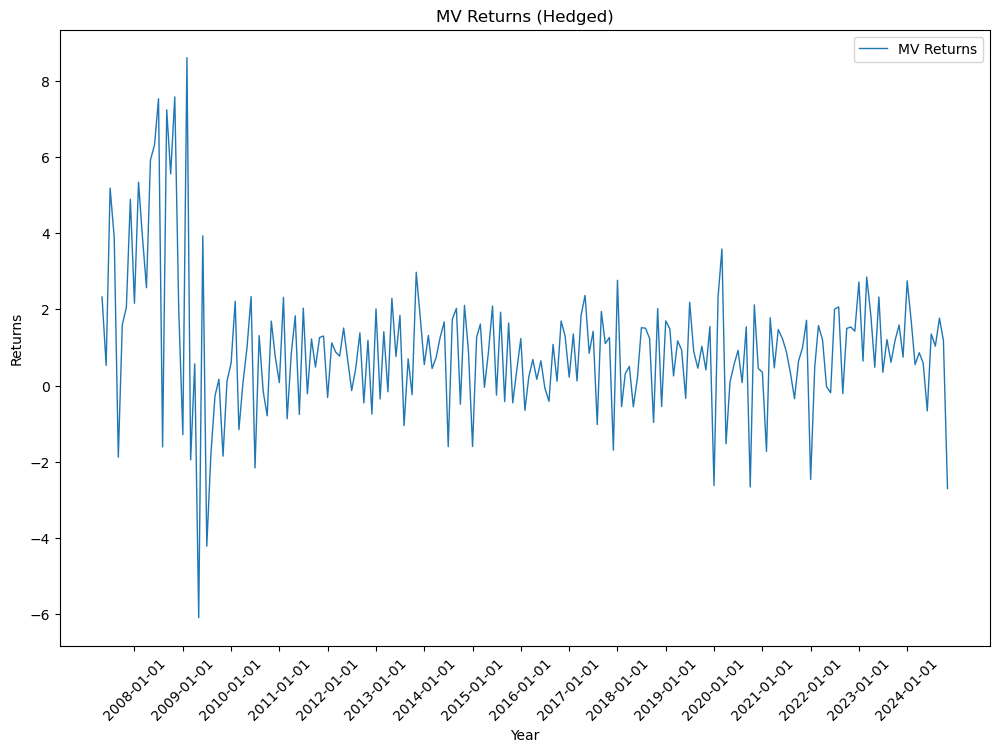

In [3691]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
mv_weights_hedged['date'] = pd.to_datetime(mv_weights_hedged['date'])
ax.plot(mv_weights_hedged['date'], mv_weights_hedged['mv_return'], linestyle='-', linewidth=1, label='MV Returns')

ax.set_xticks(pd.date_range(start=mv_weights_hedged['date'].min(), end=mv_weights_hedged['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('MV Returns (Hedged)')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

In [3692]:
df

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,04-2002,-0.010538,0.012587,-0.011617,0.056094,0.036820,-0.001806,-0.049600
1,05-2002,0.013428,0.033256,0.015840,0.061906,0.034877,0.004702,-0.010510
2,06-2002,-0.044850,-0.051421,-0.032251,-0.041866,-0.039197,-0.037508,-0.070259
3,07-2002,-0.117957,-0.059533,-0.122706,-0.066380,-0.147091,-0.101053,-0.081125
4,08-2002,-0.002077,0.025970,-0.000348,-0.041213,0.007842,0.015599,0.007949
...,...,...,...,...,...,...,...,...
267,07-2024,0.018647,0.035730,0.019748,0.072474,0.050481,0.039456,0.019878
268,08-2024,0.025529,0.021983,0.025336,-0.001815,0.017400,0.029770,0.021572
269,09-2024,-0.010247,0.022941,0.007013,-0.059865,-0.027682,-0.030240,0.020969
270,10-2024,-0.075214,-0.037250,-0.045202,-0.008310,-0.052857,-0.040088,-0.008298


In [3693]:
r_f

,mcaldt,tmytm
0,2002-02-01,0.016895
1,2002-03-01,0.017327
2,2002-04-01,0.017098
3,2002-05-01,0.017528
4,2002-06-01,0.016895
...,...,...
271,2024-09-01,0.052564
272,2024-10-01,0.045916
273,2024-11-01,0.045024
274,2024-12-01,0.041699


In [3694]:
r_f['mcaldt'].dt.strftime('%m-%Y').astype(str)

0      02-2002
1      03-2002
2      04-2002
3      05-2002
4      06-2002
        ...   
271    09-2024
272    10-2024
273    11-2024
274    12-2024
275    01-2025
Name: mcaldt, Length: 276, dtype: object

In [3695]:
df['date'].astype(str)

0      04-2002
1      05-2002
2      06-2002
3      07-2002
4      08-2002
        ...   
267    07-2024
268    08-2024
269    09-2024
270    10-2024
271    11-2024
Name: date, Length: 272, dtype: object

In [3696]:
# Unhedged returns
import numpy as np
import pandas as pd

# 1. Drop the date column to get just the returns matrix
risk_free = r_f[r_f['mcaldt'].dt.strftime('%m-%Y').astype(str).isin(df['date'].astype(str))].reset_index(drop=True)
# print(risk_free)
rets = df.drop(columns='date').reset_index(drop=True)    # shape T×7


# 2. Prepare an empty DataFrame for the MV weights (same shape)
mv_weights_unhedged = pd.DataFrame(
    np.nan,
    index=rets.index,
    columns=rets.columns
)

window = 60

for t in range(window, len(rets)):
    # take the past 60 months of returns, ending at t−1
    window_rets = rets.iloc[t-window:t]                   # shape (window × 7)
    window_rf   = risk_free.iloc[t-window:t]               # shape (window,)

    # Subtract row‐wise by specifying axis=0:
    window_data = window_rets.sub(window_rf['tmytm'], axis=0)     # (60×7) array
    # print(window_data.head())
    # print(window_rets.head())
    mu_t     = window_data.mean().values      # (7,)
    sigma_t  = window_rets.cov().values       # (7×7)

    # raw MV weights  Σ^{-1} μ
    inv_sigma = np.linalg.inv(sigma_t)
    w_raw = inv_sigma.dot(mu_t)
    mv_weights_unhedged.iloc[t] = w_raw

mv_weights_unhedged = mv_weights_unhedged.dropna().reset_index(drop=True)

mv_weights_unhedged['date'] = df['date'].iloc[window:].values

cols = ['date'] + [c for c in mv_weights_unhedged.columns if c != 'date']
mv_weights_unhedged = mv_weights_unhedged[cols]

# 7. Finally compute the strategy return
#    multiply each weight by its country return and sum across countries
rets_truncated = rets.iloc[window:].reset_index(drop=True)
risk_free_truncated = risk_free.iloc[window:].reset_index(drop=True)
mv_weights_unhedged['mv_return'] = risk_free_truncated['tmytm'] + ((mv_weights_unhedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['tmytm'], axis=0)).sum(axis=1))

mv_weights_unhedged

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA,mv_return
0,04-2007,5.823270,6.666973,19.299562,-2.526114,-13.985277,-2.688131,-34.873022,0.568402
1,05-2007,5.930296,6.691167,18.948418,-3.699314,-12.483970,-4.534305,-33.282289,0.991549
2,06-2007,5.469223,6.821768,20.226868,-4.258950,-14.721507,-4.069022,-32.335490,2.438257
3,07-2007,3.873991,5.766705,22.948944,-4.400426,-15.380564,-3.283388,-35.236292,1.372002
4,08-2007,1.142732,4.600083,28.953891,-4.299289,-20.848159,-2.474486,-38.633922,1.866106
...,...,...,...,...,...,...,...,...,...
207,07-2024,6.540784,-1.724099,4.970777,-9.496860,-12.008230,-8.812295,7.725290,-0.590029
208,08-2024,5.407912,-1.164530,4.806847,-8.144712,-10.480211,-7.947852,5.815883,0.636153
209,09-2024,5.232006,-1.282493,5.196266,-8.408401,-10.869568,-7.657167,5.927854,1.789583
210,10-2024,5.725995,-0.649657,5.175627,-9.536970,-9.322156,-9.671884,5.600100,0.900902


C:\Users\eddli\AppData\Local\Temp\ipykernel_31684\826007671.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mv_weights_unhedged['date'] = pd.to_datetime(mv_weights_unhedged['date'])


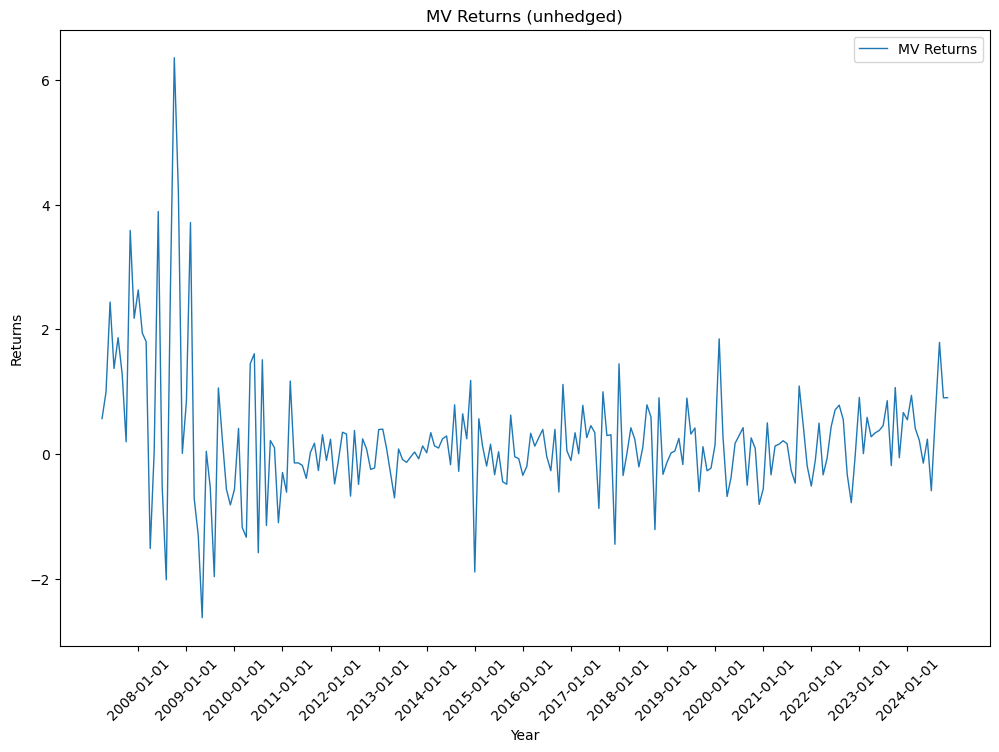

In [3697]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
mv_weights_unhedged['date'] = pd.to_datetime(mv_weights_unhedged['date'])
ax.plot(mv_weights_unhedged['date'], mv_weights_unhedged['mv_return'], linestyle='-', linewidth=1, label='MV Returns')

ax.set_xticks(pd.date_range(start=mv_weights_unhedged['date'].min(), end=mv_weights_unhedged['date'].max(), freq='YS'))
ax.tick_params(axis='x', rotation=45)

ax.set_title('MV Returns (unhedged)')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

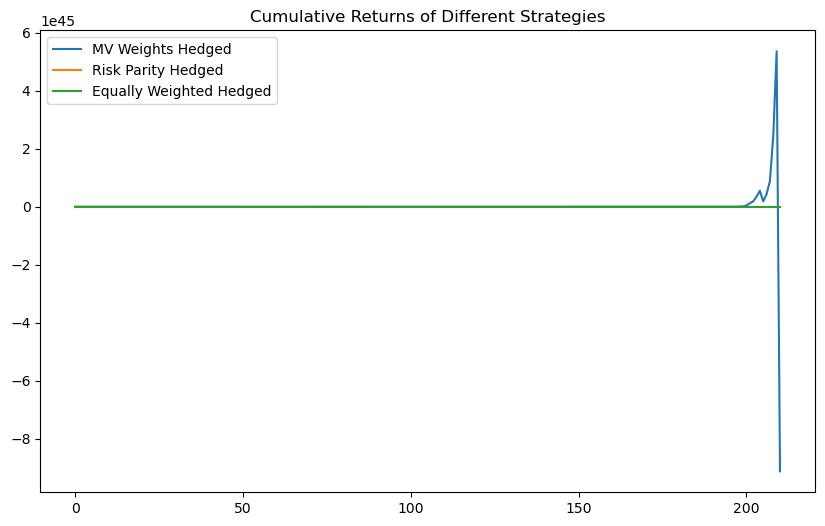

In [3698]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
(mv_weights_hedged['mv_return'] + 1).cumprod().plot(label='MV Weights Hedged')
(hedged_risk_parity['return'].reset_index(drop=True) + 1).cumprod().plot(label='Risk Parity Hedged')
(equally_weighted_hedged['returns'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Equally Weighted Hedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

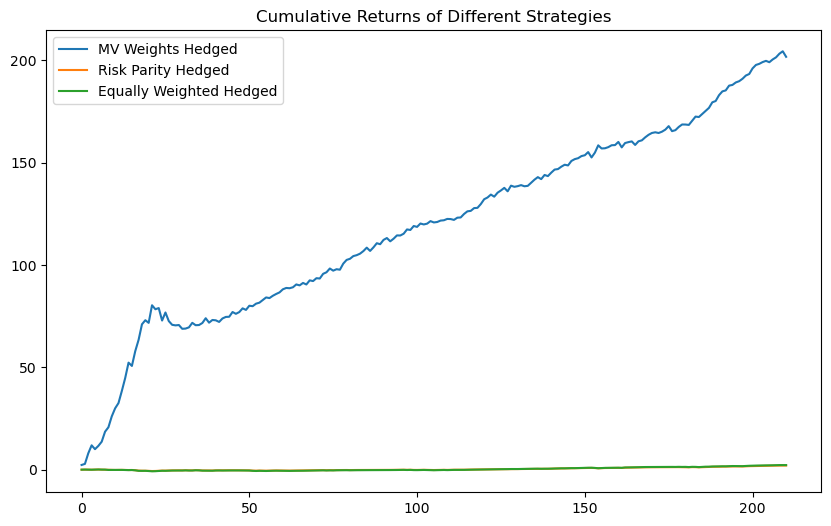

In [3699]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
mv_weights_hedged['mv_return'].cumsum().plot(label='MV Weights Hedged')
hedged_risk_parity['return'].reset_index(drop=True).cumsum().plot(label='Risk Parity Hedged')
equally_weighted_hedged['returns'].iloc[60:].reset_index(drop=True).cumsum().plot(label='Equally Weighted Hedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

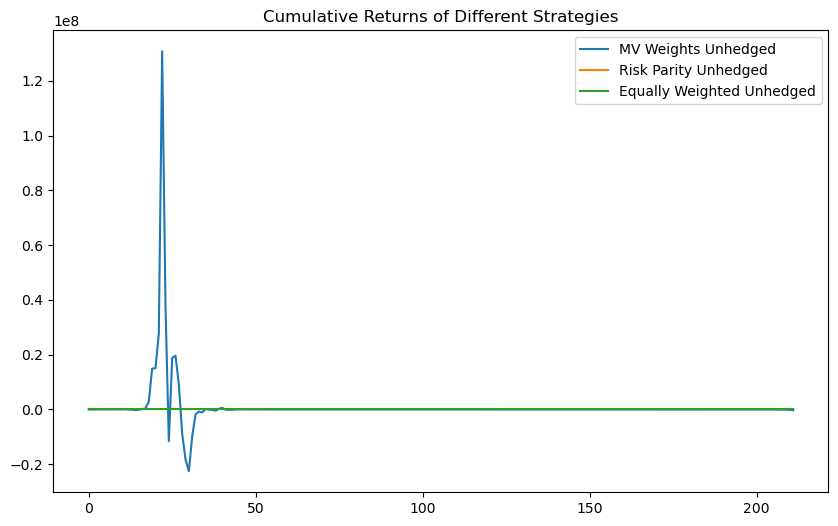

In [3700]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
(mv_weights_unhedged['mv_return'] + 1).cumprod().plot(label='MV Weights Unhedged')
(unhedged_risk_parity['return'].reset_index(drop=True) + 1).cumprod().plot(label='Risk Parity Unhedged')
(equally_weighted_unhedged['returns'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Equally Weighted Unhedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

# 4. Equity Index Momentum Strategy

***4.a***

In [3701]:
# 1a. shift your series by 1 to drop the return in t-1 (the “skip” month)
# Ensure date column is not shifted
lagged = hedged_returns.drop(columns='date').shift(1)

# 1b. rolling‐window product over the prior 11 months
#     .rolling(window=11).apply(np.prod) gives ∏(1 + R) over each 11‐month block
cumret = lagged.add(1) \
               .rolling(window=11) \
               .apply(np.prod, raw=True) \
               .subtract(1)

print(cumret.head(20))

      France  Australia   Germany     Japan  Switzerland   Britain       USA
1        NaN        NaN       NaN       NaN          NaN       NaN       NaN
2        NaN        NaN       NaN       NaN          NaN       NaN       NaN
3        NaN        NaN       NaN       NaN          NaN       NaN       NaN
4        NaN        NaN       NaN       NaN          NaN       NaN       NaN
5        NaN        NaN       NaN       NaN          NaN       NaN       NaN
6        NaN        NaN       NaN       NaN          NaN       NaN       NaN
7        NaN        NaN       NaN       NaN          NaN       NaN       NaN
8        NaN        NaN       NaN       NaN          NaN       NaN       NaN
9        NaN        NaN       NaN       NaN          NaN       NaN       NaN
10       NaN        NaN       NaN       NaN          NaN       NaN       NaN
11       NaN        NaN       NaN       NaN          NaN       NaN       NaN
12 -0.479609  -0.415348 -0.531710 -0.131505    -0.305697 -0.463626 -0.195358

In [3702]:
ranks = cumret.rank(axis=1, method='first')    # lowest cumret→1, highest→N
ranks.head(20)

,France,Australia,Germany,Japan,Switzerland,Britain,USA
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3703]:
N = hedged_returns.drop(columns='date').shape[1]
print(N)

7


In [3704]:
w = ranks.subtract(4).div(N-1)
# this gives weights summing to zero and gross exposure=1
print(w.head(20))

      France  Australia   Germany     Japan  Switzerland   Britain       USA
1        NaN        NaN       NaN       NaN          NaN       NaN       NaN
2        NaN        NaN       NaN       NaN          NaN       NaN       NaN
3        NaN        NaN       NaN       NaN          NaN       NaN       NaN
4        NaN        NaN       NaN       NaN          NaN       NaN       NaN
5        NaN        NaN       NaN       NaN          NaN       NaN       NaN
6        NaN        NaN       NaN       NaN          NaN       NaN       NaN
7        NaN        NaN       NaN       NaN          NaN       NaN       NaN
8        NaN        NaN       NaN       NaN          NaN       NaN       NaN
9        NaN        NaN       NaN       NaN          NaN       NaN       NaN
10       NaN        NaN       NaN       NaN          NaN       NaN       NaN
11       NaN        NaN       NaN       NaN          NaN       NaN       NaN
12 -0.333333        0.0 -0.500000  0.500000     0.166667 -0.166667  0.333333

In [3705]:
# assume `w` is your weight-DataFrame aligned with hedged_returns
mom_return = (w * hedged_returns).sum(axis=1)

# put it all together
momentum = pd.DataFrame({
    'weight_'+col: w[col] for col in w.columns
})
momentum['momentum_return'] = mom_return.values
# Ensure date column is correctly aligned
momentum['date'] = hedged_returns['date']
momentum = momentum.dropna()

momentum = momentum.reset_index(drop=True)

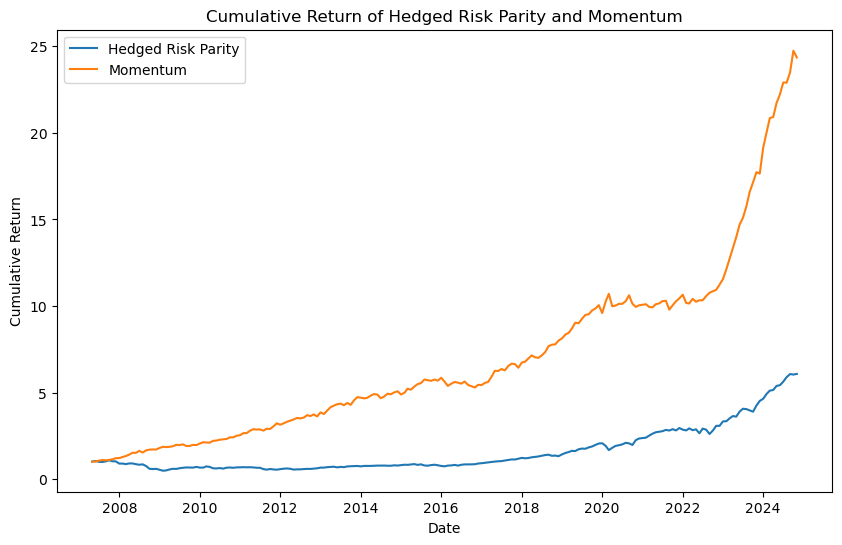

In [3706]:
import matplotlib.pyplot as plt

# Plotting the cumulative return of hedged risk parity and momentum
plt.figure(figsize=(10, 6))
plt.plot(hedged_risk_parity.date, (1 + hedged_risk_parity['return']).cumprod().reset_index(drop=True), label='Hedged Risk Parity')
plt.plot(momentum[momentum['date'] >= hedged_risk_parity['date'].min()].date, (1 + momentum[momentum['date'] >= hedged_risk_parity['date'].min()]['momentum_return']).cumprod().reset_index(drop=True), label='Momentum')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Hedged Risk Parity and Momentum')
plt.legend()
plt.show()


In [3707]:
# Merge the momentum and hedged risk parity dataframes on the 'date' column
div_mom_returns = pd.merge(momentum[['date', 'momentum_return']], hedged_risk_parity[['date', 'return']], on='date', how='inner')

# Rename the 'return' column to 'DIV_return'
div_mom_returns = div_mom_returns.rename(columns={'return': 'DIV_return'})

# Display the merged dataframe
div_mom_returns

,date,momentum_return,DIV_return
0,2007-05-01,0.025983,0.026387
1,2007-06-01,0.000625,0.031988
2,2007-07-01,0.053572,-0.045981
3,2007-08-01,0.030946,-0.007421
4,2007-09-01,-0.016168,0.034854
...,...,...,...
206,2024-07-01,0.030841,0.037123
207,2024-08-01,-0.000424,0.046618
208,2024-09-01,0.025970,0.030019
209,2024-10-01,0.053110,-0.004912


***4.b***

In [3708]:
# Calculate the long strategy returns
long_strategy, short_strategy = pd.DataFrame(), pd.DataFrame()
short_strategy['date'], long_strategy['date'] = hedged_returns['date'], hedged_returns['date']

long_strategy['return'] = (w[w > 0] * hedged_returns.drop(columns='date')).sum(axis=1)

# Calculate the short strategy returns
short_strategy['return'] = (w[w < 0] * hedged_returns.drop(columns='date')).sum(axis=1)

long_strategy['excess_return'] = long_strategy['return'] - r_f[r_f['mcaldt'].isin(long_strategy['date'])]['tmytm']
short_strategy['excess_return'] = short_strategy['return'] - r_f[r_f['mcaldt'].isin(short_strategy['date'])]['tmytm']

long_strategy, short_strategy = long_strategy.iloc[11:].reset_index(drop=True), short_strategy.iloc[11:].reset_index(drop=True)

In [3709]:
print('long leg : \n', long_strategy['return'].describe())
long_strategy_sharpe = long_strategy['excess_return'].mean() / long_strategy['return'].std()
print('Long Strategy Sharpe Ratio: ', long_strategy_sharpe)

print('\nshort leg : \n', short_strategy['return'].describe())
short_strategy_sharpe = short_strategy['excess_return'].mean() / short_strategy['return'].std()
print('Short Strategy Sharpe Ratio: ', short_strategy_sharpe)

long leg : 
 count    260.000000
mean       0.020627
std        0.044106
min       -0.167901
25%       -0.004634
50%        0.026346
75%        0.048886
max        0.121511
Name: return, dtype: float64
Long Strategy Sharpe Ratio:  0.13671425186507744

short leg : 
 count    260.000000
mean      -0.000860
std        0.048650
min       -0.177121
25%       -0.027937
50%       -0.008005
75%        0.024015
max        0.193534
Name: return, dtype: float64
Short Strategy Sharpe Ratio:  -0.31772146507937976


In [3710]:
# Momentum mean and std
print('momentum strategy : \n', momentum['momentum_return'].describe())

momentum strategy : 
 count    260.000000
mean       0.019767
std        0.029402
min       -0.103402
25%        0.000513
50%        0.021963
75%        0.040192
max        0.092140
Name: momentum_return, dtype: float64


In [3711]:
# Momentum Sharpe Ratio
momentum['excess_return'] = momentum['momentum_return'].values - r_f['tmytm'].iloc[13:273].values
momentum_strategy_sharpe = momentum['excess_return'].mean() / momentum['momentum_return'].std()
print('Momentum Strategy Sharpe Ratio: ', momentum_strategy_sharpe)

Momentum Strategy Sharpe Ratio:  0.17132051465849135


In [3712]:
#Hypothesis testing
from scipy.stats import ttest_1samp

# Perform the t-test
t_stat, p_val = ttest_1samp(momentum['momentum_return'], 0)

print('T-statistic: ', t_stat)
print('P-value: ', p_val)

if p_val < 0.05:
    print('Reject the null hypothesis: The average return of momentum might be different than 0')
else:
    print('Fail to reject the null hypothesis: The average return of momentum is not statiscally significant')

T-statistic:  10.84012509963924
P-value:  8.010193329213559e-23
Reject the null hypothesis: The average return of momentum might be different than 0


***4.c***

In [3713]:
import statsmodels.api as sm

X = div_mom_returns['DIV_return']
y = div_mom_returns['momentum_return']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        momentum_return   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     5.743
Date:                Sun, 01 Jun 2025   Prob (F-statistic):             0.0174
Time:                        17:55:03   Log-Likelihood:                 462.40
No. Observations:                 211   AIC:                            -920.8
Df Residuals:                     209   BIC:                            -914.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0166      0.002      8.664      0.000       0.013       0.020
DIV_return    -0.0974      0.041     -2.396      0.017      -0.178      -0.017
==============================================================================
Omnibus:                        4.158   Durbin-Watson:                   2.128
Prob(Omnibus):                  0.125   Jarque-Bera (JB):                3.855
Skew:                          -0.325   Prob(JB):                        0.146
Kurtosis:                       3.131   Cond. No.                         21.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""